In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import functions as F

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import col
from pyspark.ml.evaluation import RegressionEvaluator

# Set visual style for the charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [8]:
# SparkSession (like the wpo)
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("AnimeRecommender") \
    .config("spark.ui.port", "4040") \
    .config("spark.hadoop.fs.defaultFS", "file:///") \
    .config("spark.driver.extraJavaOptions", "-Duser.name=admin") \
    .config("spark.driver.extraJavaOptions", "-Dsun.security.auth.login.config=C:/dev/null") \
    .getOrCreate()

In [9]:
#pre processed data

reviews_data = spark.read.csv("../data/preprocessed/reviews.csv", header=True, inferSchema=True)
anime_data = spark.read.csv("../data/preprocessed/animes.csv", header=True, inferSchema=True)

# The profiles need to be represented in numbers.
# Tried using cast like the intstructions but didn't work due to 
review_indexed = StringIndexer(inputCol="profile", outputCol="user_id")
reviews_data_indexed = review_indexed.fit(reviews_data).transform(reviews_data)

start_data = reviews_data_indexed.select(
    col("user_id").cast("integer"),
    col("anime_id").cast("integer"),
    col("score").cast("float")
)

# final_data = clean_sparse_data(start_data, min_user_reviews=5, min_anime_reviews=10)



start_data.show(7)

+-------+--------+-----+
|user_id|anime_id|score|
+-------+--------+-----+
|     32|   34096|  8.0|
|   1104|   34599| 10.0|
|   1825|   28891|  7.0|
|   3796|    2904|  9.0|
|   9589|    4181| 10.0|
|   9872|    2904| 10.0|
|    554|   16664|  6.0|
+-------+--------+-----+
only showing top 7 rows



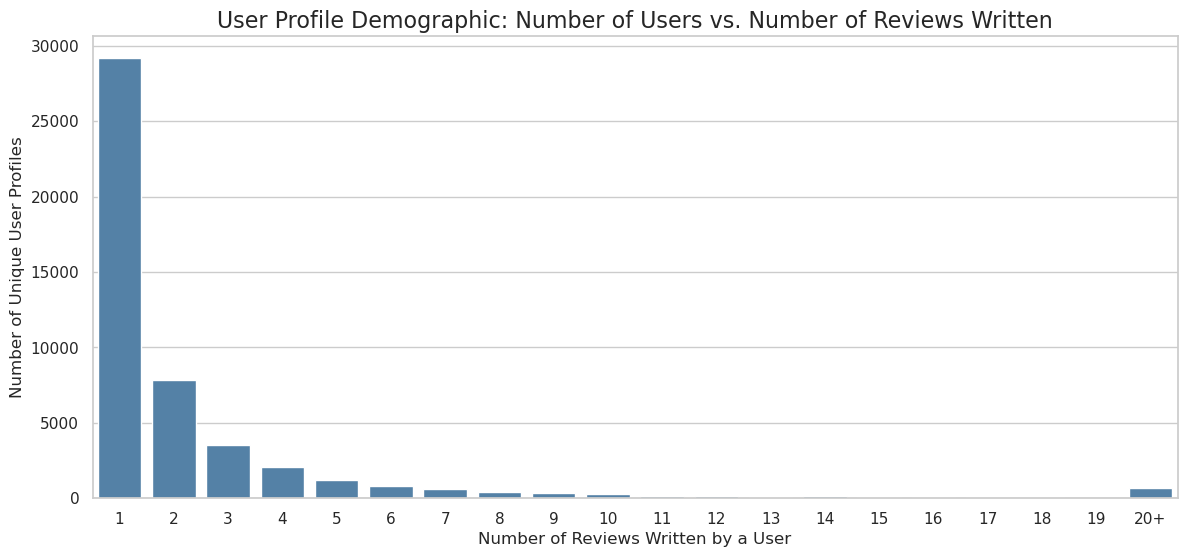

In [12]:
# 1. Count reviews per user
user_counts_df = start_data.groupBy("user_id").agg(F.count("anime_id").alias("review_count"))

# 2. Group the counts to see the demographic distribution
user_distribution = user_counts_df.groupBy("review_count").agg(F.count("user_id").alias("num_users")).toPandas()

# 3. Create a 'capped' column so the chart doesn't stretch out to infinity
user_distribution['display_count'] = user_distribution['review_count'].apply(lambda x: str(x) if x < 20 else '20+')
chart1_data = user_distribution.groupby('display_count')['num_users'].sum().reset_index()

# Sort properly (1, 2, 3... 19, 20+)
chart1_data['sort_key'] = chart1_data['display_count'].apply(lambda x: int(x) if x != '20+' else 999)
chart1_data = chart1_data.sort_values('sort_key')

# 4. Plot the Bar Chart (Simplified to a single clean color)
plt.figure(figsize=(14, 6))
sns.barplot(data=chart1_data, x="display_count", y="num_users", color="steelblue")
plt.title("User Profile Demographic: Number of Users vs. Number of Reviews Written", fontsize=16)
plt.xlabel("Number of Reviews Written by a User", fontsize=12)
plt.ylabel("Number of Unique User Profiles", fontsize=12)
plt.xticks(rotation=0)
plt.show()

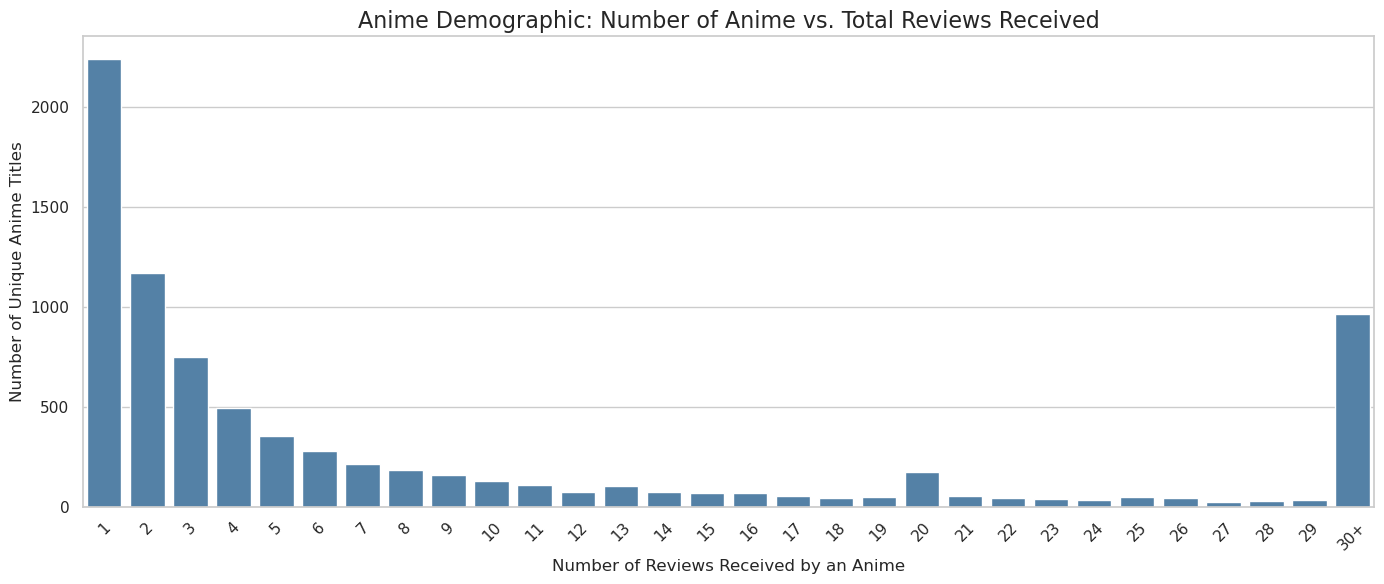

In [13]:
# 1. Count reviews per anime
anime_counts_df = start_data.groupBy("anime_id").agg(F.count("user_id").alias("review_count"))

# 2. Group the counts to see item demographics
anime_distribution = anime_counts_df.groupBy("review_count").agg(F.count("anime_id").alias("num_animes")).toPandas()

# 3. Cap at 30+ reviews for readability
anime_distribution['display_count'] = anime_distribution['review_count'].apply(lambda x: str(x) if x < 30 else '30+')
chart2_data = anime_distribution.groupby('display_count')['num_animes'].sum().reset_index()

# Sort columns numerically
chart2_data['sort_key'] = chart2_data['display_count'].apply(lambda x: int(x) if x != '30+' else 999)
chart2_data = chart2_data.sort_values('sort_key')

# 4. Plot the Bar Chart (Simplified to a single clean color)
plt.figure(figsize=(14, 6))
sns.barplot(data=chart2_data, x="display_count", y="num_animes", color="steelblue")
plt.title("Anime Demographic: Number of Anime vs. Total Reviews Received", fontsize=16)
plt.xlabel("Number of Reviews Received by an Anime", fontsize=12)
plt.ylabel("Number of Unique Anime Titles", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# 1. Map training activity level to predictions
user_counts = train_data.groupBy("user_id").agg(F.count("anime_id").alias("activity"))
df_perf = final_predictions.join(user_counts, on="user_id", how="inner")

# 2. Calculate Squared Error per row
df_perf = df_perf.withColumn("sq_err", (F.col("score") - F.col("final_prediction")) ** 2)

# 3. Calculate RMSE per activity level and send to Pandas
rmse_df = df_perf.groupBy("activity").agg(F.sqrt(F.avg("sq_err")).alias("rmse")).toPandas()

# 4. Group into clean display buckets
rmse_df['bucket'] = rmse_df['activity'].apply(lambda x: str(x) if x <= 10 else '11-20' if x <= 20 else '21+')
chart_data = rmse_df.groupby('bucket')['rmse'].mean().reset_index()

# Sort buckets chronologically
bucket_order = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11-20', '21+']
chart_data['bucket'] = pd.Categorical(chart_data['bucket'], categories=bucket_order, ordered=True)
chart_data = chart_data.sort_values('bucket').reset_index(drop=True)

# 5. Plot clean, single-color bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=chart_data, x="bucket", y="rmse", color="steelblue")
plt.title("RMSE by User Profile Sparsity", fontsize=14)
plt.xlabel("Number of Training Reviews", fontsize=11)
plt.ylabel("RMSE", fontsize=11)
plt.ylim(0, max(chart_data['rmse']) + 0.2)

# Add simple labels over bars
for idx, row in chart_data.iterrows():
    plt.text(idx, row['rmse'] + 0.02, f"{row['rmse']:.2f}", ha="center", fontsize=9)

plt.show()

NameError: name 'train_data' is not defined